# Stock Forecast With ARIMA

## Packages

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import (
    RBF,
    WhiteKernel,
    ConstantKernel
)

## File Reading And Cleaning

In [2]:
prices = pd.read_csv("C:/Users/Judit/Desktop/hw/25_26/Project/data/all/prices-split-adjusted.csv")
funds = pd.read_csv("C:/Users/Judit/Desktop/hw/25_26/Project/data/all/fundamentals.csv")
secs = pd.read_csv("C:/Users/Judit/Desktop/hw/25_26/Project/data/all/securities.csv")

In [3]:
## cleaning the column names to make them the same structure from  every file

def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r"[^a-z0-9]+", "_", regex=True)
          .str.strip("_")
    )
    return df
prices = clean_cols(prices)
funds = clean_cols(funds)
secs = clean_cols(secs)

In [4]:
# map potential alternative names for revenue if needed

revenue_col_candidates = [
    "total_revenue", "revenue", "total_sales", "total_revenue_(ttm)"
]

fund_revenue_col = next((c for c in revenue_col_candidates if c in funds.columns), None)

if fund_revenue_col is None:
    raise KeyError("Could not find a revenue column in fundamentals. "
                   "Please rename the revenue column to one of: "
                   f"{', '.join(revenue_col_candidates)}")
    
    
# Ensure we have ticker keys consistent
# securities file might have 'ticker_symbol' or 'symbol' — align to 'symbol'
if "symbol" not in prices.columns:
    raise KeyError("Prices must contain a 'symbol' column.")
if "ticker_symbol" not in funds.columns:
    # fallback if fundamentals already use 'symbol'
    if "symbol" in funds.columns:
        funds = funds.rename(columns={"symbol": "ticker_symbol"})
    else:
        raise KeyError("Fundamentals must contain 'ticker_symbol' or 'symbol'.")
if "ticker_symbol" not in secs.columns:
    if "symbol" in secs.columns:
        secs = secs.rename(columns={"symbol": "ticker_symbol"})
    elif "ticker" in secs.columns:
        secs = secs.rename(columns={"ticker": "ticker_symbol"})
    else:
        raise KeyError("Securities must contain 'ticker_symbol' or 'symbol'/'ticker'.")

In [5]:
#Parse dates

prices["date"] = pd.to_datetime(prices["date"])
funds["period_ending"] = pd.to_datetime(funds["period_ending"], errors = "coerce")

# Drop fundamentals rows with invalid period dates
funds = funds.dropna(subset=["period_ending"])

# Keep only columns we need from each dataset
prices = prices[["date", "symbol", "open", "close", "low", "high", "volume"]].copy()
secs_cols_needed = ["ticker_symbol", "security", "gics_sector", "gics_sub_industry"]

for c in secs_cols_needed:
    if c not in secs.columns:
        secs[c] = np.nan
secs = secs[secs_cols_needed].drop_duplicates("ticker_symbol")

funds = funds[["ticker_symbol", "period_ending", "operating_margin", fund_revenue_col]].rename(
    columns = {fund_revenue_col: "revenue"}
)

In [6]:
# each ticker -> assign revenue

prices = prices.sort_values(["symbol", "date"]).reset_index(drop=True)
funds = funds.sort_values(["ticker_symbol", "period_ending"]).reset_index(drop=True)
# Rename for alignment
funds = funds.rename(columns={"ticker_symbol": "symbol", "period_ending": "report_date"})

merged_list = []
for sym, p in prices.groupby("symbol", sort=False):
    f = funds[funds["symbol"] == sym]
    if f.empty:
        # no fundamentals for the symbol-> attach NaN revenue
        p2 = p.copy()
        p2["revenue"] = np.nan
        p2["operating_margin"] = np.nan
        merged_list.append(p2)
        continue
        
    # merge_asof requires both frames sorted by the merge key
    p_sorted = p.sort_values("date")
    f_sorted = f.sort_values("report_date")
    
    # asof: for each price date, get the most recent fundamentals report at or before that date
    p_enriched = pd.merge_asof(
        p_sorted,
        f_sorted[["report_date", "revenue", "operating_margin"]], 
        left_on="date",
        right_on="report_date",
        direction="backward"
    )
    p_enriched = p_enriched.drop(columns=["report_date"])
    merged_list.append(p_enriched)
    
prices_with_rev = pd.concat(merged_list, ignore_index=True)

In [7]:
prices_with_rev.head()

,date,symbol,open,close,low,high,volume,revenue,operating_margin
0,2010-01-04,A,22.453504,22.389128,22.267525,22.625180,3815500.0,NaN,NaN
1,2010-01-05,A,22.324749,22.145923,22.002861,22.331903,4186000.0,NaN,NaN
2,2010-01-06,A,22.067240,22.067240,22.002861,22.174536,3243700.0,NaN,NaN
3,2010-01-07,A,22.017168,22.038626,21.816881,22.045780,3095100.0,NaN,NaN
4,2010-01-08,A,21.917024,22.031474,21.745350,22.067240,3733900.0,NaN,NaN


### Log return + Final Data

In [8]:
# log_return_t = ln(close_t / close_{t-1}) per symbol
prices_with_rev = prices_with_rev.sort_values(["symbol", "date"])
prices_with_rev["log_return"] = (
    prices_with_rev.groupby("symbol")["close"]
    .apply(lambda s: np.log(s).diff())
    .values
)

#add securities
final = prices_with_rev.merge(
    secs,
    how="left",
    left_on="symbol",
    right_on="ticker_symbol"
).drop(columns=["ticker_symbol"])

# final columns with reorde
final = final[[
    "date",
    "symbol",
    "security",
    "gics_sector",
    "gics_sub_industry",
    "open",
    "close",
    "low",
    "high",
    "volume",
    "revenue",
    "operating_margin",
    "log_return"
]].sort_values(["symbol", "date"]).reset_index(drop=True)


print(final.head(10))

        date symbol                  security  gics_sector  \
0 2010-01-04      A  Agilent Technologies Inc  Health Care   
1 2010-01-05      A  Agilent Technologies Inc  Health Care   
2 2010-01-06      A  Agilent Technologies Inc  Health Care   
3 2010-01-07      A  Agilent Technologies Inc  Health Care   
4 2010-01-08      A  Agilent Technologies Inc  Health Care   
5 2010-01-11      A  Agilent Technologies Inc  Health Care   
6 2010-01-12      A  Agilent Technologies Inc  Health Care   
7 2010-01-13      A  Agilent Technologies Inc  Health Care   
8 2010-01-14      A  Agilent Technologies Inc  Health Care   
9 2010-01-15      A  Agilent Technologies Inc  Health Care   

       gics_sub_industry       open      close        low       high  \
0  Health Care Equipment  22.453504  22.389128  22.267525  22.625180   
1  Health Care Equipment  22.324749  22.145923  22.002861  22.331903   
2  Health Care Equipment  22.067240  22.067240  22.002861  22.174536   
3  Health Care Equipment  22.

### Apple(AAPL ticker) Plotting

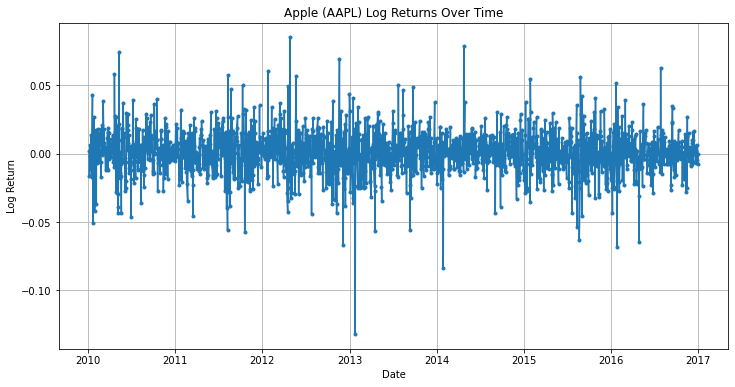

In [9]:
# Filter data for Apple
apple_data = final[final["symbol"] == "AAPL"]

# Plot log returns over time
plt.figure(figsize = (12, 6))
plt.plot(apple_data["date"], apple_data["log_return"], marker='o', linestyle='-', markersize=3)
plt.title("Apple (AAPL) Log Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

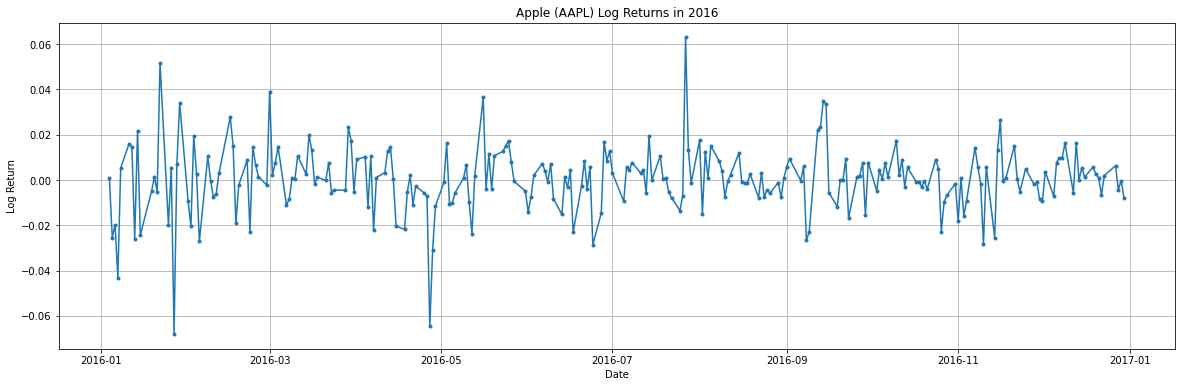

In [36]:
# Better visibility -> only showing the end of the period

# Filter data for Apple (AAPL) in 2017
apple_data_2016 = final[
    (final["symbol"] == "AAPL") &
    (final["date"].dt.year == 2016)
]

# Plot log returns over time for 2017
plt.figure(figsize=(20, 6))
plt.plot(apple_data_2016["date"], apple_data_2016["log_return"], marker='o', linestyle='-', markersize=3)
plt.title("Apple (AAPL) Log Returns in 2016")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

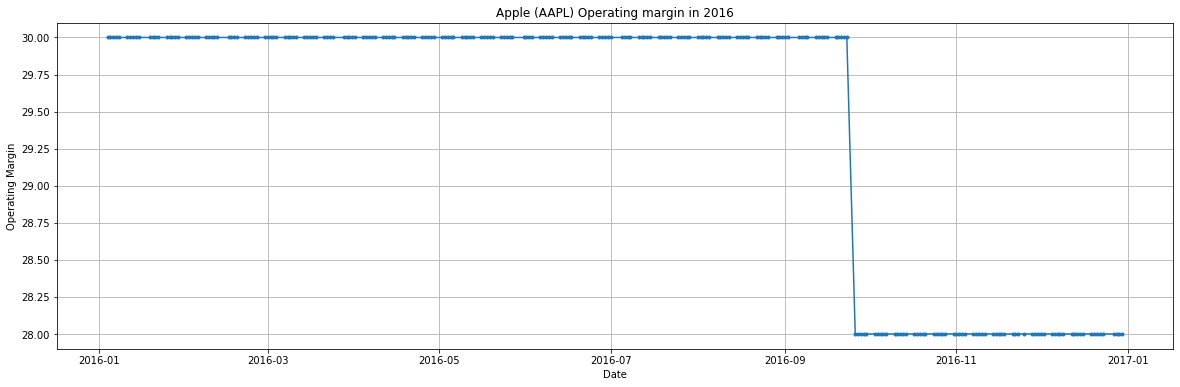

In [12]:
# Filter data for Apple (AAPL) in 2017
apple_data_2016_margin = final[
    (final["symbol"] == "AAPL") &
    (final["date"].dt.year == 2016)
]

# Plot log returns over time for 2017
plt.figure(figsize = (20, 6))
plt.plot(apple_data_2016["date"], apple_data_2016["operating_margin"], marker='o', linestyle='-', markersize=3)
plt.title("Apple (AAPL) Operating margin in 2016")
plt.xlabel("Date")
plt.ylabel("Operating Margin")
plt.grid(True)
plt.show()

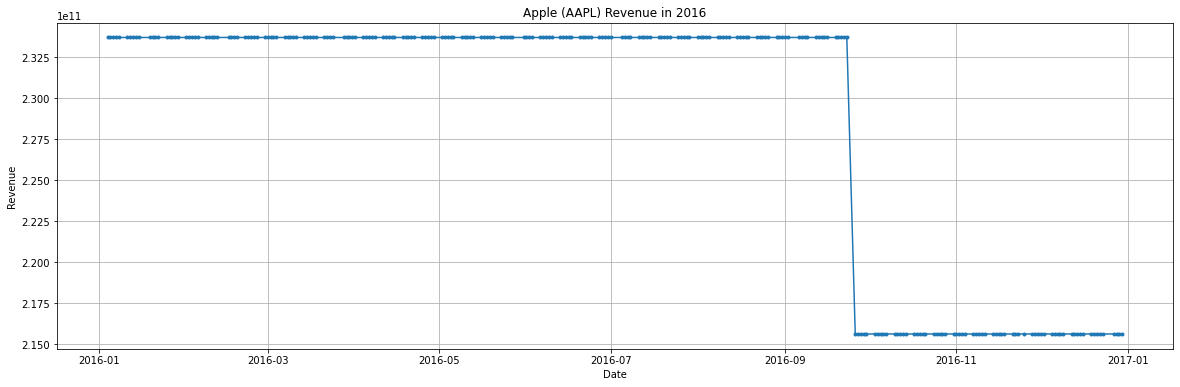

In [13]:
# Filter data for Apple (AAPL) in 2017
apple_data_2016_margin = final[
    (final["symbol"] == "AAPL") &
    (final["date"].dt.year == 2016)
]

# Plot log returns over time for 2017
plt.figure(figsize = (20, 6))
plt.plot(apple_data_2016["date"], apple_data_2016["revenue"], marker='o', linestyle='-', markersize=3)
plt.title("Apple (AAPL) Revenue in 2016")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

## ARIMAX + Bootstrap

- Not just a value, but a range in the forecast (value, median forecast and 95% confidence range)

In [14]:
# prepare data

df = final.copy()

df = df[[
    "date",
    "symbol",
    "security",
    "gics_sector",
    "revenue",
    "operating_margin",
    "log_return"
]]

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["symbol", "date"])

In [15]:
# clean fundamentals
df["operating_margin"] = (
    df.groupby("symbol")["operating_margin"]
    .transform(lambda x: x.ffill().bfill())
)

df["revenue"] = (
    df.groupby("symbol")["revenue"]
    .transform(lambda x: x.ffill().bfill())
)

In [16]:
# log_revenue
df["log_revenue"] = np.log1p(df["revenue"])

# remove missing targets
df = df.dropna(subset=["log_return"])

In [17]:
# feature engineeringff

# Lagged returns
df["lag1_return"] = (
    df.groupby("symbol")["log_return"]
    .shift(1)
)

df["lag2_return"] = (
    df.groupby("symbol")["log_return"]
    .shift(2)
)

# Rolling volatility
df["rolling_volatility"] = (
    df.groupby("symbol")["log_return"]
    .transform(lambda x: x.rolling(5).std())
)

# Rolling momentum
df["rolling_mean"] = (
    df.groupby("symbol")["log_return"]
    .transform(lambda x: x.rolling(5).mean())
)

# Remove NaNs from lags/rolling
df = df.dropna()


In [18]:
all_predictions = []

In [19]:
N_BOOTSTRAPS = 500

In [20]:
symbols = df["symbol"].unique()

for symbol in symbols:

    stock = df[df["symbol"] == symbol].copy()

    # Skip very small datasets
    if len(stock) < 50:
        continue

    stock = stock.sort_values("date")

    #target
    y = stock["log_return"]

    #exogenous variables
    X = stock[[
        "operating_margin",
        "log_revenue",
        "lag1_return",
        "lag2_return",
        "rolling_volatility",
        "rolling_mean"
    ]]

    #train, test split
    train_size = int(len(stock) * 0.8)

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    #ARIMAX model
    try:

        model = SARIMAX(
            y_train,
            exog = X_train,
            order = (3, 0, 2),
            enforce_stationarity = False,
            enforce_invertibility = False
        )

        model_fit = model.fit(disp=False)

        # forecast
        base_forecast = model_fit.forecast(
            steps = len(y_test),
            exog = X_test
        )

        # BOOSTRAP forecast
        # Get model residuals
        residuals = model_fit.resid

        # Store bootstrap simulations
        bootstrap_forecasts = np.zeros(
            (len(y_test), N_BOOTSTRAPS)
        )


        for i in range(N_BOOTSTRAPS):

            # Resample residuals WITH replacement
            sampled_residuals = np.random.choice(
                residuals,
                size=len(y_test),
                replace=True
            )

            # Simulated forecast path
            simulated_forecast = (
                base_forecast.values +
                sampled_residuals
            )

            bootstrap_forecasts[:, i] = simulated_forecast

        # Forecast Ranges
        # Median forecast
        median_forecast = np.median(
            bootstrap_forecasts,
            axis=1
        )

        # 95% lower bound
        lower_95 = np.percentile(
            bootstrap_forecasts,
            2.5,
            axis = 1
        )

        # 95% upper bound
        upper_95 = np.percentile(
            bootstrap_forecasts,
            97.5,
            axis = 1
        )

        # save reuslt
        test_results = stock.iloc[train_size:].copy()

        test_results["forecast_median"] = median_forecast
        test_results["forecast_lower_95"] = lower_95
        test_results["forecast_upper_95"] = upper_95

        all_predictions.append(test_results)

    except Exception as e:

        print(f"{symbol} failed: {e}")

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', Valu

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local

...

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local

In [21]:
predictions_df = pd.concat(all_predictions)

In [38]:
# evaluation
rmse = np.sqrt(
    mean_squared_error(
        predictions_df["log_return"],
        predictions_df["forecast_median"]
    )
)

print(f"RMSE: {rmse}")

RMSE: 355731207.88645214


### Apple (AAPL ticket) Plotting 

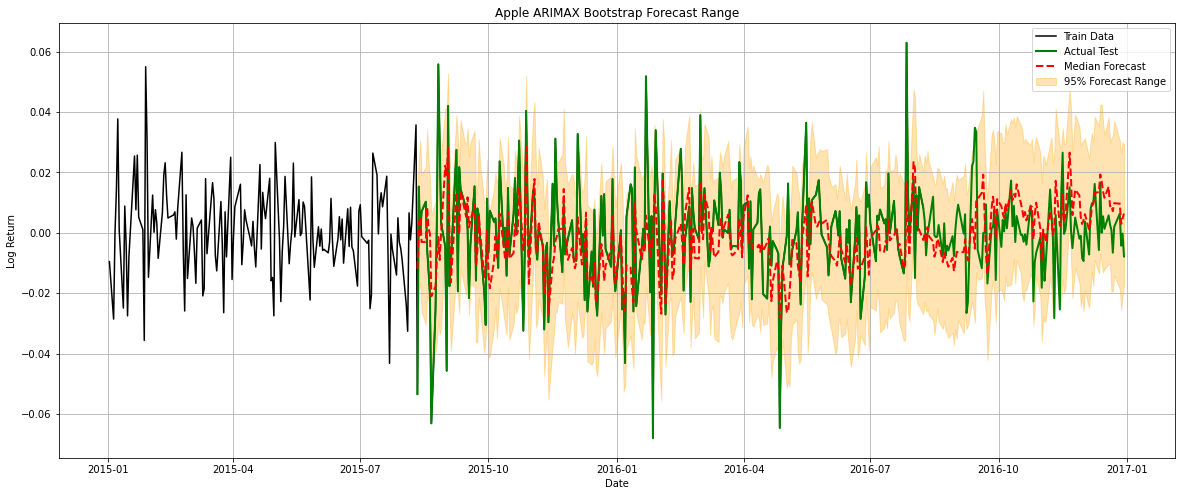

           date symbol                 security  gics_sector       revenue  \
3172 2015-08-11    AAL  American Airlines Group  Industrials  4.265000e+10   
3173 2015-08-12    AAL  American Airlines Group  Industrials  4.265000e+10   
3174 2015-08-13    AAL  American Airlines Group  Industrials  4.265000e+10   
3175 2015-08-14    AAL  American Airlines Group  Industrials  4.265000e+10   
3176 2015-08-17    AAL  American Airlines Group  Industrials  4.265000e+10   

      operating_margin  log_return  log_revenue  lag1_return  lag2_return  \
3172              10.0    0.024178    24.476293     0.004569    -0.016494   
3173              10.0   -0.004224    24.476293     0.024178     0.004569   
3174              10.0    0.003521    24.476293    -0.004224     0.024178   
3175              10.0    0.004909    24.476293     0.003521    -0.004224   
3176              10.0    0.024647    24.476293     0.004909     0.003521   

      rolling_volatility  rolling_mean  forecast_median  forecast_lo

In [23]:
# ============================================================
# APPLE PLOT
# ============================================================

apple_plot = predictions_df[
    (predictions_df["symbol"] == "AAPL") &
    (predictions_df["date"].dt.year >= 2015)
].copy()

apple_full = df[
    (df["symbol"] == "AAPL") &
    (df["date"].dt.year >= 2015)
].copy()

train_size = int(len(apple_full) * 0.8)

apple_train = apple_full.iloc[:train_size]

plt.figure(figsize=(20, 8))

# train data
plt.plot(
    apple_train["date"],
    apple_train["log_return"],
    label="Train Data",
    color="black"
)

# test data
plt.plot(
    apple_plot["date"],
    apple_plot["log_return"],
    label="Actual Test",
    color="green",
    linewidth=2
)

#forecasted median
plt.plot(
    apple_plot["date"],
    apple_plot["forecast_median"],
    label="Median Forecast",
    color="red",
    linestyle="--",
    linewidth=2
)

#forecasted range
plt.fill_between(
    apple_plot["date"],
    apple_plot["forecast_lower_95"],
    apple_plot["forecast_upper_95"],
    color="orange",
    alpha=0.3,
    label="95% Forecast Range"
)

# plot
plt.title("Apple ARIMAX Bootstrap Forecast Range")

plt.xlabel("Date")
plt.ylabel("Log Return")

plt.legend()

plt.grid(True)

plt.show()

print(predictions_df.head())

## ARIMAX + Gaussian Process

In [24]:
model2_predictions = []

In [25]:
# train model2 for each stock
symbols = df["symbol"].unique()

for symbol in symbols:

    stock = df[df["symbol"] == symbol].copy()

    # Skip tiny datasets
    if len(stock) < 50:
        continue

    stock = stock.sort_values("date")
    y = stock["log_return"]
    
    #exogenous variables
    X = stock[[
        "operating_margin",
        "log_revenue",
        "lag1_return",
        "lag2_return",
        "rolling_volatility",
        "rolling_mean"
    ]]

    # train, test splitting
    train_size = int(len(stock) * 0.8)

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    # ARIMAX - model2
    try:

        model2 = SARIMAX(
            y_train,
            exog=X_train,
            order=(3, 0, 2),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model2_fit = model2.fit(disp=False)
        
        #forecast
        arimax_forecast = model2_fit.forecast(
            steps=len(y_test),
            exog=X_test
        )

        residuals = (
            y_train -
            model2_fit.fittedvalues
        )


        # time index for GP
        X_gp_train = np.arange(
            len(residuals)
        ).reshape(-1, 1)

        X_gp_test = np.arange(
            len(residuals),
            len(residuals) + len(y_test)
        ).reshape(-1, 1)

        # kernel for GP
        kernel = (
            ConstantKernel(1.0)
            *
            RBF(length_scale=20.0)
            +
            WhiteKernel(noise_level=0.1)
        )

        # gp model
        gp_model = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=3,
            random_state=42
        )

        # train gp
        gp_model.fit(
            X_gp_train,
            residuals
        )

        # gp prediction
        gp_mean, gp_std = gp_model.predict(
            X_gp_test,
            return_std=True
        )

        # forecast final : arimax + gp
        final_forecast = (
            arimax_forecast.values +
            gp_mean
        )

        # confidence ranges
        lower_95 = (
            final_forecast -
            1.96 * gp_std
        )

        upper_95 = (
            final_forecast +
            1.96 * gp_std
        )

        #result
        test_results = stock.iloc[train_size:].copy()
        test_results["forecast_mean_model2"] = final_forecast
        test_results["forecast_lower_95_model2"] = lower_95
        test_results["forecast_upper_95_model2"] = upper_95
        model2_predictions.append(test_results)

    except Exception as e:

        print(f"{symbol} model2 failed: {e}")

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


AAL model2 completed


c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


AAP model2 completed


c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


...

ZBH model2 completed


c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


ZION model2 completed


c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:579: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:379: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


ZTS model2 completed


In [26]:
model2_predictions_df = pd.concat(model2_predictions)

In [39]:
# model 2 evaluation

model2_rmse = np.sqrt(
    mean_squared_error(
        model2_predictions_df["log_return"],
        model2_predictions_df["forecast_mean_model2"]
    )
)

print(f"RMSE: {model2_rmse}")

RMSE: 355731207.8864497


### Apple (AAPL ticker) plotting

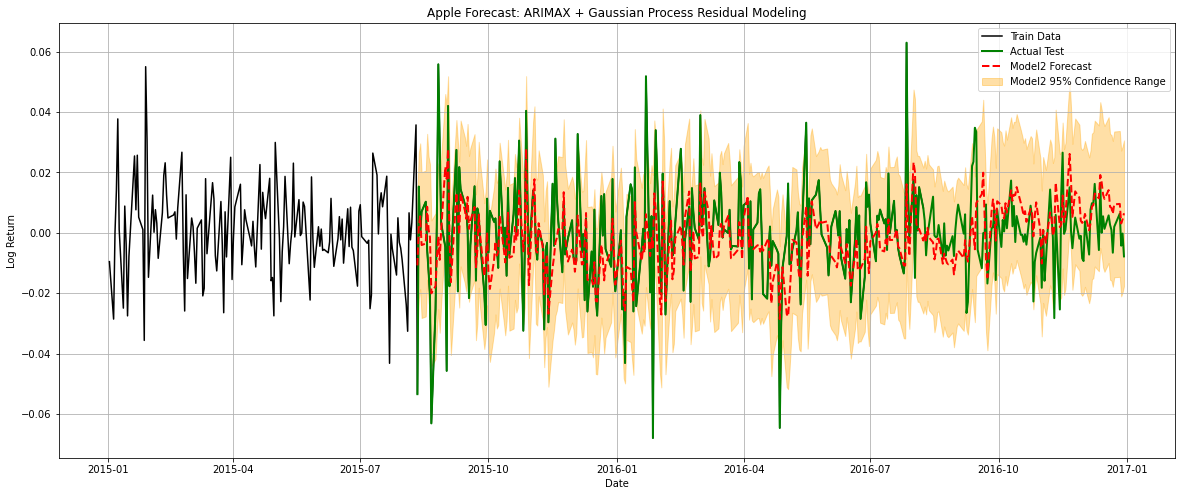

           date symbol                 security  gics_sector       revenue  \
3172 2015-08-11    AAL  American Airlines Group  Industrials  4.265000e+10   
3173 2015-08-12    AAL  American Airlines Group  Industrials  4.265000e+10   
3174 2015-08-13    AAL  American Airlines Group  Industrials  4.265000e+10   
3175 2015-08-14    AAL  American Airlines Group  Industrials  4.265000e+10   
3176 2015-08-17    AAL  American Airlines Group  Industrials  4.265000e+10   

      operating_margin  log_return  log_revenue  lag1_return  lag2_return  \
3172              10.0    0.024178    24.476293     0.004569    -0.016494   
3173              10.0   -0.004224    24.476293     0.024178     0.004569   
3174              10.0    0.003521    24.476293    -0.004224     0.024178   
3175              10.0    0.004909    24.476293     0.003521    -0.004224   
3176              10.0    0.024647    24.476293     0.004909     0.003521   

      rolling_volatility  rolling_mean  forecast_mean_model2  \
3172

In [33]:
apple_model2 = model2_predictions_df[
    (model2_predictions_df["symbol"] == "AAPL") &
    (model2_predictions_df["date"].dt.year >= 2015)
].copy()

apple_full = df[
    (df["symbol"] == "AAPL") &
    (df["date"].dt.year >= 2015)
].copy()

train_size = int(len(apple_full) * 0.8)
apple_train = apple_full.iloc[:train_size]
plt.figure(figsize = (20, 8))

# train data
plt.plot(
    apple_train["date"],
    apple_train["log_return"],
    label="Train Data",
    color="black"
)

# test data
plt.plot(
    apple_model2["date"],
    apple_model2["log_return"],
    label="Actual Test",
    color="green",
    linewidth=2
)

# forecast
plt.plot(
    apple_model2["date"],
    apple_model2["forecast_mean_model2"],
    label="Model2 Forecast",
    color="red",
    linestyle="--",
    linewidth=2
)

# confidence range
plt.fill_between(
    apple_model2["date"],
    apple_model2["forecast_lower_95_model2"],
    apple_model2["forecast_upper_95_model2"],
    color="orange",
    alpha=0.35,
    label="Model2 95% Confidence Range"
)

plt.title("Apple Forecast: ARIMAX + Gaussian Process Residual Modeling")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True)
plt.show()


print(model2_predictions_df.head())